In [1]:
import os
os.environ["GYRO_DATA_DIR"] = "/home/Felix/Documents/Physics_Work/Project_Codes/Gyrokinetic_Simulations/"


In [2]:
import controller

In [3]:
tglf_list = ["tglf", "tglf_F", "tglf_M"]

In [4]:

gs2_pyroscan,GS2_convention, tglf_pyroscan_dict = controller.load_list("n40","Beta_Prime_Scan",tglf_list,read_netcdf=True,write_netcdf=False)

Loading GS2 PyroScan from: /home/Felix/Documents/Physics_Work/Project_Codes/Gyrokinetic_Simulations/GS2/Runs/Beta_Prime_Scan/n40/parameter_scan_gs2/ky_0.1000_beta_0.1000/gs2.in
see if that's geting called


/home/Felix/Documents/Physics_Work/Project_Codes/Beta_Prime_Scan/pyrokinetics/src/pyrokinetics/pyro.py:1732: UserWarning: Explicitly set value of beta (0.09999999999999999 beta_ref_ee_B0_gs20000) is inconsistent with value from physical reference values (0.09609377154804474 beta_ref_ee_B0_gs20000)
  warnings.warn(


see if that's geting called
what about this one


/home/Felix/Documents/Physics_Work/Project_Codes/Beta_Prime_Scan/pyrokinetics/src/pyrokinetics/pyro.py:1732: UserWarning: Explicitly set value of beta (0.09092868468130633 beta_ref_ee_B0_gs20001) is inconsistent with value from physical reference values (0.09609377154804474 beta_ref_ee_B0_gs20001)
  warnings.warn(
/home/Felix/Documents/Physics_Work/Project_Codes/Beta_Prime_Scan/pyrokinetics/src/pyrokinetics/pyro.py:346: UserWarning: Setting gk_code to TGLF without first reading a gyrokinetics file of that type. Creating a new context using the default template file for TGLF and data from the previous context (if available).
  warnings.warn(warn_msg, UserWarning)


see if that's geting called
what about this one


/home/Felix/Documents/Physics_Work/Project_Codes/Beta_Prime_Scan/pyrokinetics/src/pyrokinetics/pyro.py:1732: UserWarning: Explicitly set value of beta (0.09092868468130633 beta_ref_ee_B0_gs20002) is inconsistent with value from physical reference values (0.09609377154804474 beta_ref_ee_B0_gs20002)
  warnings.warn(


see if that's geting called
what about this one


/home/Felix/Documents/Physics_Work/Project_Codes/Beta_Prime_Scan/pyrokinetics/src/pyrokinetics/pyro.py:1732: UserWarning: Explicitly set value of beta (0.09092868468130633 beta_ref_ee_B0_gs20003) is inconsistent with value from physical reference values (0.09609377154804474 beta_ref_ee_B0_gs20003)
  warnings.warn(


In [5]:
print(gs2_pyroscan.gk_output)

<pyrokinetics.PyroScanGKOutput>
(Wraps <xarray.Dataset>) Size: 368kB
Dimensions:                (ky: 4, beta: 19, field: 3, theta: 97, species: 3)
Coordinates:
  * field                  (field) <U4 48B 'phi' 'apar' 'bpar'
  * species                (species) <U8 96B 'electron' 'ion1' 'ion2'
  * ky                     (ky) float64 32B 0.1 0.2 0.3 0.4
  * beta                   (beta) float64 152B 0.01 0.02 0.03 ... 0.17 0.18 0.19
  * theta                  (theta) float64 776B -9.425 -9.229 ... 9.229 9.425
Data variables:
    growth_rate            (ky, beta) float64 608B [vref_nrl_gs20000/lref_minor_radius_gs20000] ...
    mode_frequency         (ky, beta) float64 608B [vref_nrl_gs20000/lref_minor_radius_gs20000] ...
    growth_rate_tolerance  (ky, beta) float64 608B [] 0.0001515 ... 0.01838
    eigenfunctions         (ky, beta, field, theta) complex128 354kB [] (0.01...
    particle               (ky, beta, field, species) float64 5kB [nref_electron_gs20000·rhoref_pyro_gs20000²·vref_

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

def plot_growth_rate_difference(gs2_output, tglf_output, 
                                metric="absolute",
                                cmap="seismic",
                                ax=None):
    """
    Plot a beta–ky heatmap of the difference in growth rate between 
    a GS2 PyroScanGKOutput (ground truth) and a TGLF PyroScanGKOutput.
    
    Parameters
    ----------
    gs2_output : PyroScanGKOutput
        Ground-truth simulation output.
    tglf_output : PyroScanGKOutput
        Model/surrogate output to compare.
    metric : {"absolute", "relative"}
        absolute  → Δγ = γ_tglf – γ_gs2
        relative  → Δγ/|γ_gs2|
    cmap : str
        Matplotlib colormap name.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 5))
    else:
        fig = ax.figure

    # Extract coordinates
    ky = gs2_output.coords["ky"].data
    beta = gs2_output.coords["beta"].data

    # Extract growth rate arrays (ky, beta)
    gr_gs2 = gs2_output["growth_rate"].values
    gr_tglf = tglf_output["growth_rate"].sel(mode=0).values

    # Compute difference metric
    if metric == "absolute":
        diff = (gr_tglf - gr_gs2)
    elif metric == "relative":
        diff = ((gr_tglf - gr_gs2) / np.abs(gr_gs2))
    else:
        raise ValueError("metric must be 'absolute' or 'relative'")

    # Set symmetric color scale for diverging colormap
    #vmax = np.nanmax(np.abs(diff))
    vmax = 0.5
    norm = colors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    # pcolormesh wants 2D coordinate grids
    ky_grid, beta_grid = np.meshgrid(ky, beta, indexing="ij")

    pcm = ax.pcolormesh(
        ky_grid, beta_grid, diff,
        cmap=cmap,
        norm=norm,
        shading="auto"
    )

    # Labels styled similar to your example figure
    ax.set_xlabel(r"$k_y$")
    ax.set_ylabel(r"$\beta$ (%)")
    #ax.set_xscale("log")   # optional — remove if desired

    # Colorbar above
    cbar = fig.colorbar(pcm, ax=ax, orientation="horizontal", location = "top")
    if metric == "absolute":
        cbar.set_label(r"$\Delta \gamma$", labelpad=6)
    else:
        cbar.set_label(r"$\Delta \gamma / |\gamma_{\mathrm{GS2}}|$", labelpad=6)
    plt.tight_layout()
    return fig, ax


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

def plot_frequency_difference(gs2_output, tglf_output, 
                                metric="absolute",
                                cmap="seismic",
                                ax=None):
    """
    Plot a beta–ky heatmap of the difference in growth rate between 
    a GS2 PyroScanGKOutput (ground truth) and a TGLF PyroScanGKOutput.
    
    Parameters
    ----------
    gs2_output : PyroScanGKOutput
        Ground-truth simulation output.
    tglf_output : PyroScanGKOutput
        Model/surrogate output to compare.
    metric : {"absolute", "relative"}
        absolute  → Δγ = γ_tglf – γ_gs2
        relative  → Δγ/|γ_gs2|
    cmap : str
        Matplotlib colormap name.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 5))
    else:
        fig = ax.figure

    # Extract coordinates
    ky = gs2_output.coords["ky"].data
    beta = gs2_output.coords["beta"].data

    # Extract growth rate arrays (ky, beta)
    gr_gs2 = gs2_output["mode_frequency"].values
    gr_tglf = tglf_output["mode_frequency"].sel(mode=0).values

    # Compute difference metric
    if metric == "absolute":
        diff = (gr_tglf - gr_gs2)
    elif metric == "relative":
        diff = ((gr_tglf - gr_gs2) / np.abs(gr_gs2))
    else:
        raise ValueError("metric must be 'absolute' or 'relative'")

    # Set symmetric color scale for diverging colormap
    #vmax = np.nanmax(np.abs(diff))
    vmax = 0.5
    norm = colors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    # pcolormesh wants 2D coordinate grids
    ky_grid, beta_grid = np.meshgrid(ky, beta, indexing="ij")

    pcm = ax.pcolormesh(
        ky_grid, beta_grid, diff,
        cmap=cmap,
        norm=norm,
        shading="auto"
    )

    # Labels styled similar to your example figure
    ax.set_xlabel(r"$k_y$")
    ax.set_ylabel(r"$\beta$ (%)")
    #ax.set_xscale("log")   # optional — remove if desired

    # Colorbar above
    cbar = fig.colorbar(pcm, ax=ax, orientation="horizontal", location = "top")
    if metric == "absolute":
        cbar.set_label(r"$\Delta \omega$", labelpad=6)
    else:
        cbar.set_label(r"$\Delta \omega / |\omega_{\mathrm{GS2}}|$", labelpad=6)
    plt.tight_layout()
    return fig, ax


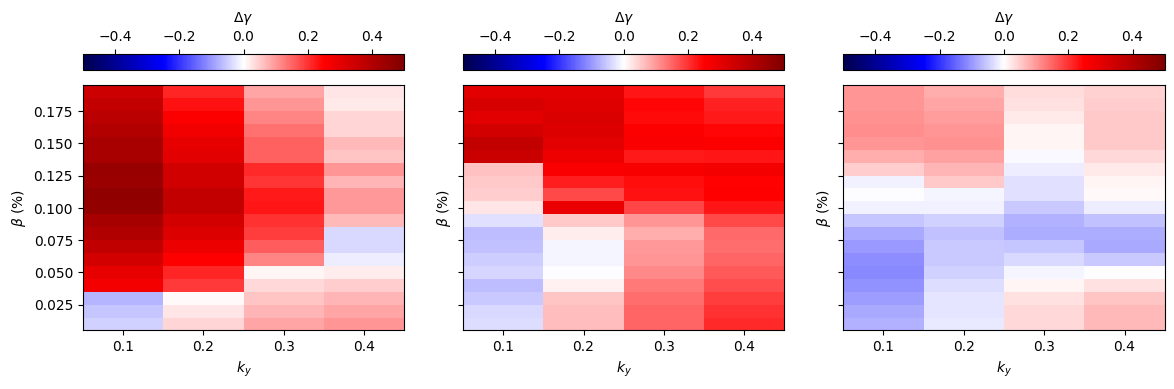

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)

plot_growth_rate_difference(gs2_pyroscan.gk_output,
                            tglf_pyroscan_dict["tglf"].gk_output,
                            metric="absolute",
                            ax=axes[0])

plot_growth_rate_difference(gs2_pyroscan.gk_output,
                            tglf_pyroscan_dict["tglf_F"].gk_output,
                            metric="absolute",
                            ax=axes[1])

plot_growth_rate_difference(gs2_pyroscan.gk_output,
                            tglf_pyroscan_dict["tglf_M"].gk_output,
                            metric="absolute",
                            ax=axes[2])

plt.tight_layout()
plt.show()


KeyError: "'PyroScanGKOutput' object does not contain 'frequency'"

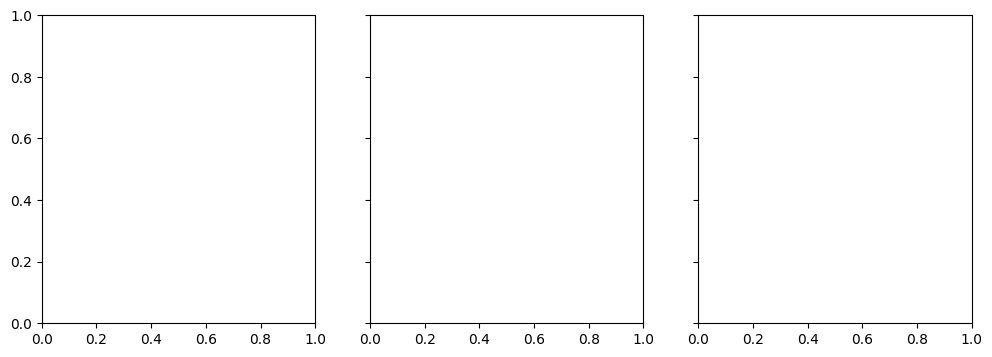

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)

plot_frequency_difference(gs2_pyroscan.gk_output,
                            tglf_pyroscan_dict["tglf"].gk_output,
                            metric="absolute",
                            ax=axes[0])

plot_frequency_difference(gs2_pyroscan.gk_output,
                            tglf_pyroscan_dict["tglf_F"].gk_output,
                            metric="absolute",
                            ax=axes[1])

plot_frequency_difference(gs2_pyroscan.gk_output,
                            tglf_pyroscan_dict["tglf_M"].gk_output,
                            metric="absolute",
                            ax=axes[2])

plt.tight_layout()
plt.show()
